In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Data
df = pd.read_csv("../data/processed/heart_clean.csv")
df = df.drop(columns=["age_bin"], errors="ignore")

X = df.drop(columns=["target"])
y = df["target"]

# Model load
model = joblib.load("../models/heart_disease_model.pkl")
print("Model loaded:", type(model))

# Same split as modeling notebook (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

C:\Users\NLP\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: <class 'sklearn.pipeline.Pipeline'>
Train: (216, 13) | Test: (54, 13)


In [4]:
pre = model.named_steps["pre"]
classifier = model.named_steps["model"]

ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(["sex", "cp", "fbs", "restecg",
                                             "exang", "slope", "ca", "thal"]))
num_names = ["age", "trestbps", "chol", "thalach", "oldpeak"]
feature_names = num_names + cat_names

X_train_trans = pre.transform(X_train)
X_test_trans  = pre.transform(X_test)

print("Transformed shape:", X_train_trans.shape)
print("Total features after encoding:", len(feature_names))

Transformed shape: (216, 28)
Total features after encoding: 28


In [5]:
explainer = shap.LinearExplainer(classifier, X_train_trans)
shap_values = explainer.shap_values(X_test_trans)
print("SHAP values shape:", shap_values.shape)

Background dataset has 216 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=216 when initializing the masker.


SHAP values shape: (54, 28)


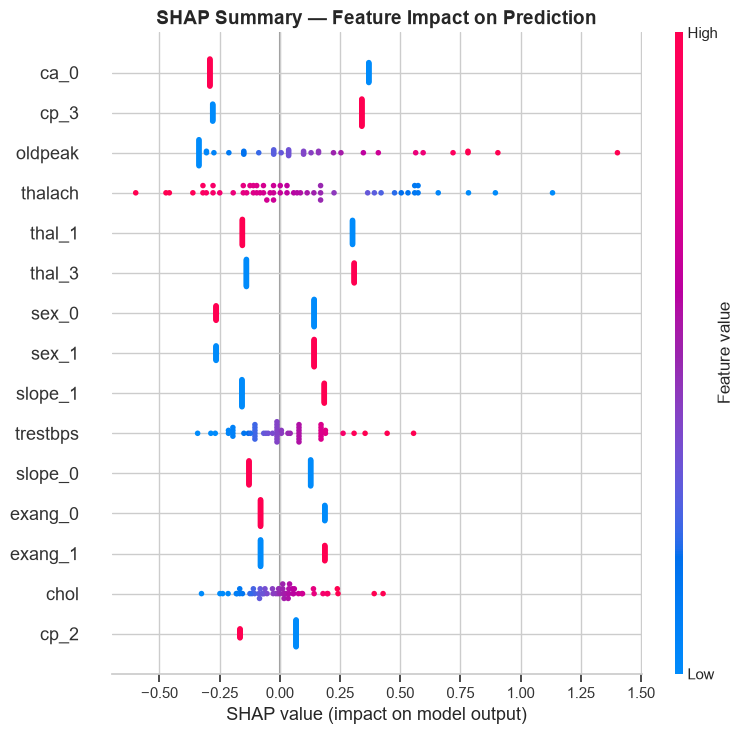

In [6]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title("SHAP Summary — Feature Impact on Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/14_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

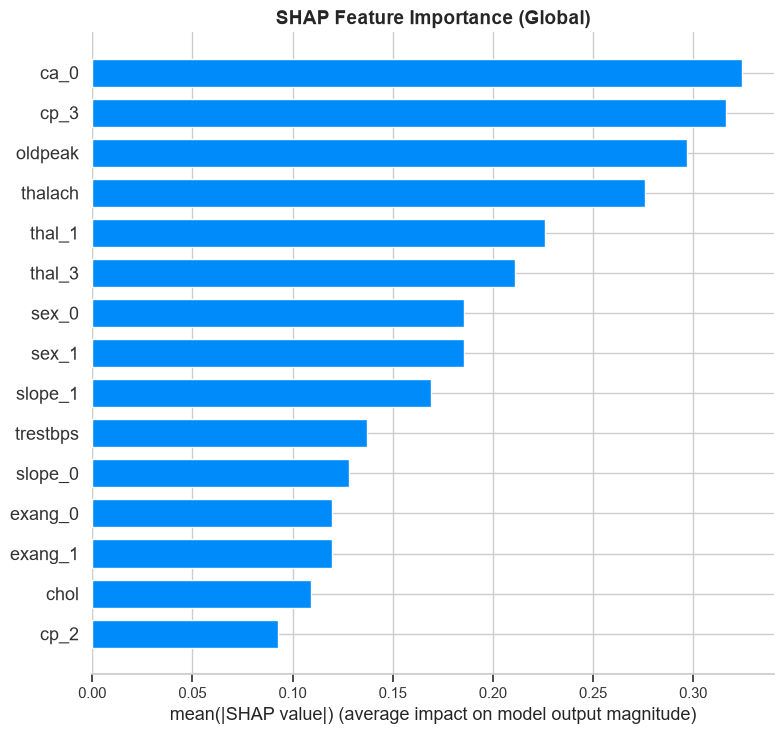

In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_trans, feature_names=feature_names,
    plot_type="bar", show=False, max_display=15
)
plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/15_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

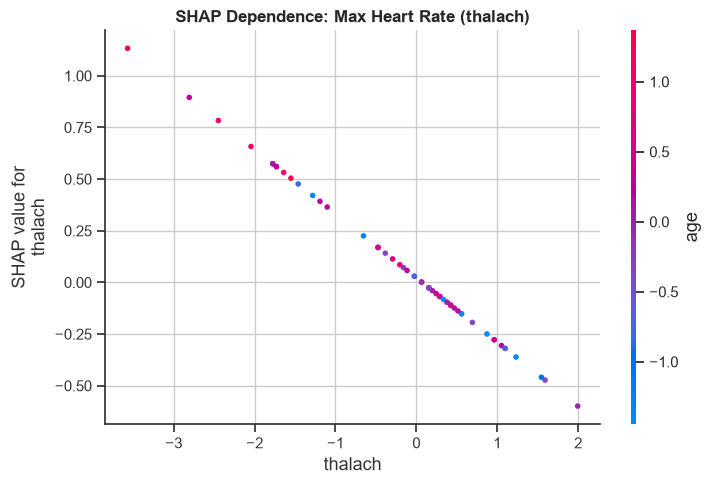

In [8]:
idx_thalach = feature_names.index("thalach")

plt.figure(figsize=(10, 6))
shap.dependence_plot(idx_thalach, shap_values, X_test_trans,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence: Max Heart Rate (thalach)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/16_shap_dependence_thalach.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

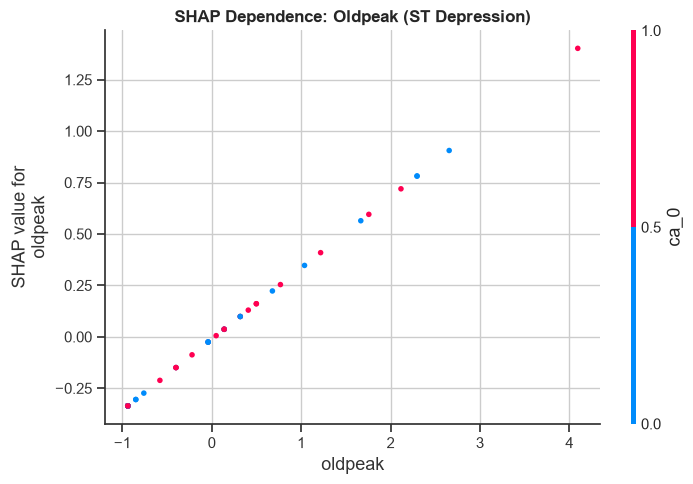

In [9]:
idx_oldpeak = feature_names.index("oldpeak")

plt.figure(figsize=(10, 6))
shap.dependence_plot(idx_oldpeak, shap_values, X_test_trans,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence: Oldpeak (ST Depression)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/17_shap_dependence_oldpeak.png", dpi=150, bbox_inches="tight")
plt.show()

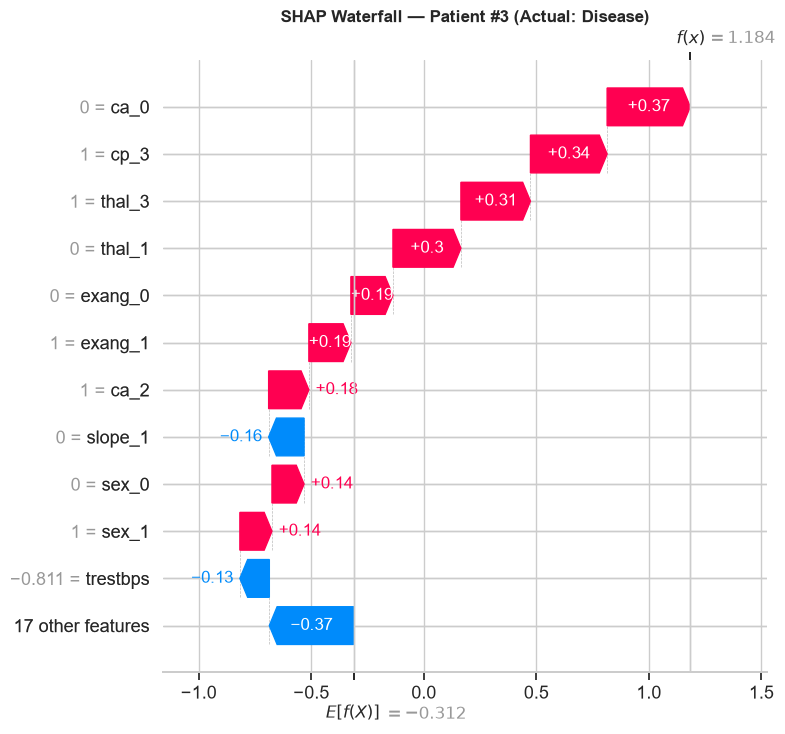

In [10]:
disease_indices = np.where(y_test.values == 1)[0]
patient_idx = disease_indices[0]

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_trans[patient_idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f"SHAP Waterfall — Patient #{patient_idx} (Actual: Disease)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/18_shap_waterfall_disease.png", dpi=150, bbox_inches="tight")
plt.show()

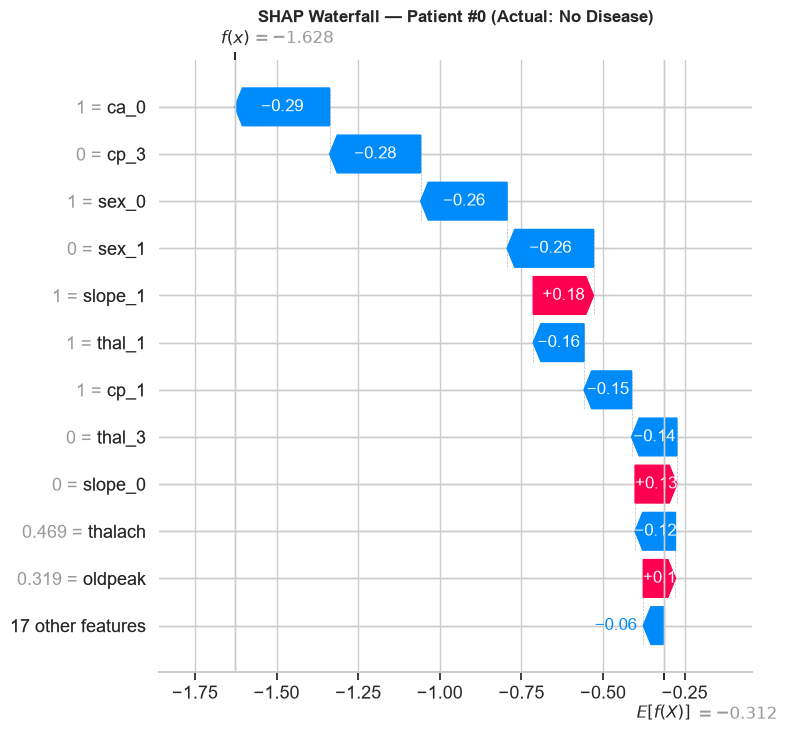

In [11]:
healthy_indices = np.where(y_test.values == 0)[0]
patient_idx = healthy_indices[0]

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_trans[patient_idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f"SHAP Waterfall — Patient #{patient_idx} (Actual: No Disease)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/19_shap_waterfall_healthy.png", dpi=150, bbox_inches="tight")
plt.show()

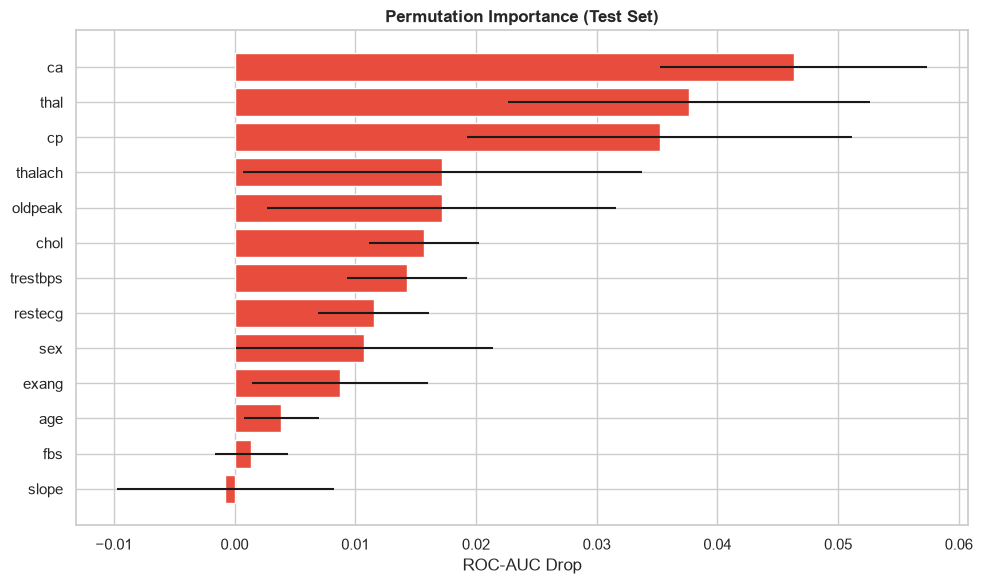

     feature  importance_mean  importance_std
11        ca         0.046319        0.011079
12      thal         0.037639        0.014997
2         cp         0.035208        0.015916
7    thalach         0.017222        0.016518
9    oldpeak         0.017153        0.014429
4       chol         0.015694        0.004588
3   trestbps         0.014306        0.004952
6    restecg         0.011528        0.004609
1        sex         0.010764        0.010676
8      exang         0.008750        0.007298
0        age         0.003889        0.003124
5        fbs         0.001389        0.003011
10     slope        -0.000764        0.008995


In [12]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=20, random_state=42,
    scoring="roc_auc", n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df["feature"], perm_df["importance_mean"],
         xerr=perm_df["importance_std"], color="#e74c3c")
plt.gca().invert_yaxis()
plt.xlabel("ROC-AUC Drop")
plt.title("Permutation Importance (Test Set)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/20_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(perm_df)
perm_df.to_csv("../reports/permutation_importance.csv", index=False)

In [13]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

shap_df.to_csv("../reports/shap_importance.csv", index=False)
print("\nSaved: reports/shap_importance.csv")

Top 15 features by mean |SHAP|:
 feature  mean_abs_shap
    ca_0       0.324158
    cp_3       0.316596
 oldpeak       0.296908
 thalach       0.275855
  thal_1       0.226053
  thal_3       0.211310
   sex_0       0.185604
   sex_1       0.185580
 slope_1       0.168991
trestbps       0.137085
 slope_0       0.128061
 exang_0       0.119615
 exang_1       0.119591
    chol       0.109111
    cp_2       0.092918

Saved: reports/shap_importance.csv


In [14]:
print("=" * 65)
print("KEY INSIGHTS FROM SHAP ANALYSIS")
print("=" * 65)

top5 = shap_df.head(5)["feature"].tolist()
print(f"\n📌 Top 5 most influential features:")
for i, f in enumerate(top5, 1):
    print(f"   {i}. {f}")

print("\n📌 Clinical interpretation:")
print("   • thalach (max heart rate): Lower = higher disease risk")
print("   • oldpeak (ST depression): Higher = higher disease risk")
print("   • cp (chest pain type): Type 3 = high risk")
print("   • ca (major vessels): More vessels = higher risk")
print("   • thal: Reversible defect = higher risk")

KEY INSIGHTS FROM SHAP ANALYSIS

📌 Top 5 most influential features:
   1. ca_0
   2. cp_3
   3. oldpeak
   4. thalach
   5. thal_1

📌 Clinical interpretation:
   • thalach (max heart rate): Lower = higher disease risk
   • oldpeak (ST depression): Higher = higher disease risk
   • cp (chest pain type): Type 3 = high risk
   • ca (major vessels): More vessels = higher risk
   • thal: Reversible defect = higher risk


In [15]:
print("=" * 60)
print("EXPLAINABILITY COMPLETE")
print("=" * 60)
print("\n✅ Figures saved: 14-20")
print("✅ CSVs saved: shap_importance.csv, permutation_importance.csv")

EXPLAINABILITY COMPLETE

✅ Figures saved: 14-20
✅ CSVs saved: shap_importance.csv, permutation_importance.csv
